# Приоритизация обращений - решение

Ниже мой подход к задаче ранжирования обращений

Кратко, что я сделал:

- Добавил признаки из `events.csv` (счётчики по типам событий, recency, разнообразие контекста), с фильтром по времени `event_ts < assignment_ts`, чтобы не было утечки.
- Проверил пропуски в табличных признаках — они не связаны с "новизной" пользователя и не системны (см. EDA ниже), поэтому отдал их модели как есть.
- Валидируюсь по времени (train — ранние даты, valid — поздние), метрика — Daily Average Precision, а не обычный AP, потому что именно она считается на скрытой выборке.
- Модель — CatBoost, потому что он нативно работает с категориальными признаками и пропусками без ручного OHE/imputation.
- Гиперпараметры подобраны через Optuna, оптимизируя Daily AP на валидации

Библиотеки: `pandas`, `scikit-learn`, `catboost`, `optuna` - все open-source, разворачиваются локально, внешние API и LLM не используются

Random seed зафиксирован везде, где есть случайность

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import optuna
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Загрузка данных

Загружаю все три файла и сразу смотрю на размеры и базовую долю целевого действия

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
df_events = pd.read_csv("data/events.csv")

print(df_train.shape, df_test.shape, df_events.shape)
print(df_train["target"].mean())

(13694, 119) (4306, 118) (254705, 7)
0.20746312253541696


## 3. EDA

Перед тем как строить признаки, проверил четыре вещи:
1. стабильность target rate по дням
2. силу категориальных признаков
3. пересечение train/test по пользователям и датам
4. природу пропусков - тут отдельно оформил проверку гипотезы

### 3.1 Target rate по дням

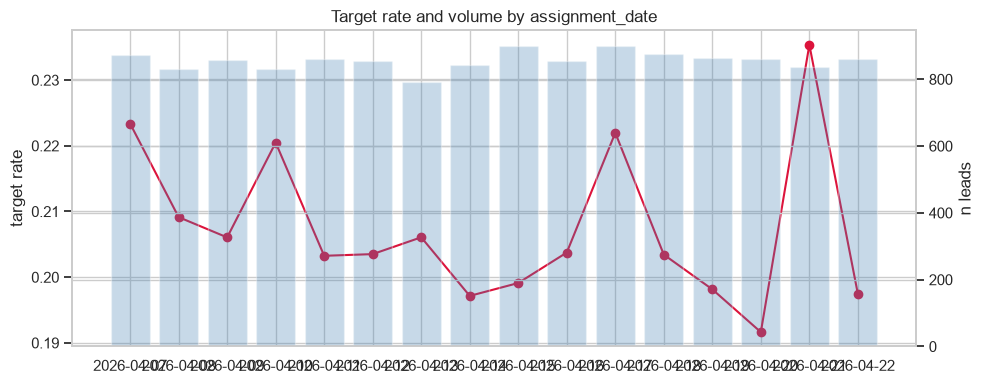

In [3]:
daily_rate = df_train.groupby("assignment_date")["target"].agg(["mean", "count"])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(daily_rate.index, daily_rate["mean"], marker="o", color="crimson")
ax2.bar(daily_rate.index, daily_rate["count"], alpha=0.3, color="steelblue")
ax1.set_ylabel("target rate")
ax2.set_ylabel("n leads")
plt.xticks(rotation=45)
plt.title("Target rate and volume by assignment_date")
plt.tight_layout()
plt.show()

Target rate колеблется в районе 0.19–0.25 без явного тренда вверх/вниз по датам — можно валидироваться по времени, не опасаясь систематического сдвига base rate

### 3.2 Target rate по категориальным признакам

In [4]:
cat_cols_eda = ["lead_source", "call_center", "region", "car_segment", "lead_channel", "user_tenure_bucket", "price_bucket"]

for col in cat_cols_eda:
    stats = df_train.groupby(col)["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print(col)
    print(stats, "\n")

lead_source
                 mean  count
lead_source                 
Model        0.265295   5688
Perf         0.195137   3167
CRM          0.147551   4839 

call_center
                 mean  count
call_center                 
voxys        0.232794   5812
external     0.188785   7882 

region
             mean  count
region                  
north    0.212546   2710
east     0.212446   2796
west     0.207220   2770
central  0.203303   2725
south    0.201634   2693 

car_segment
                 mean  count
car_segment                 
premium      0.236249   1909
budget       0.211330   4713
standard     0.201038   5780
commercial   0.179567   1292 

lead_channel
                  mean  count
lead_channel                 
retargeting   0.218612   3385
app           0.214789   3408
web           0.202956   3518
partner       0.193615   3383 

user_tenure_bucket
                        mean  count
user_tenure_bucket                 
new                 0.208930   4121
loyal            

`lead_source` и `call_center` дают заметную разницу в target rate между уровнями (например, `Model` заметно выше `CRM` в `lead_source`) - это сильные категориальные признаки. `region`, `user_tenure_bucket` и `price_bucket` почти не различаются между уровнями - сигнала там немного, но для дерева это не проблема, просто не жду от них многого

### 3.3 Пересечение train/test

In [5]:
overlap_users = set(df_train["user_id"]) & set(df_test["user_id"])

print("Общих user_id между train и test:", len(overlap_users))
print("train даты:", df_train["assignment_date"].min(), "-", df_train["assignment_date"].max())
print("test даты:", df_test["assignment_date"].min(), "-", df_test["assignment_date"].max())

Общих user_id между train и test: 0
train даты: 2026-04-07 - 2026-04-22
test даты: 2026-04-23 - 2026-04-27


Пользователи в train и test не пересекаются, test строго позже train по датам - значит, валидация по времени здесь обязательна, а не просто хорошая практика

### 3.4 Проверка гипотезы: пропуски связаны с "новизной" пользователя

В данных заметный процент пропусков почти во всех событийных агрегатах. Это могут быть новые пользователи без накопленной истории. Проверяю эту гипотезу тремя способами, беря `item_views_30d` как репрезентативную колонку с пропусками

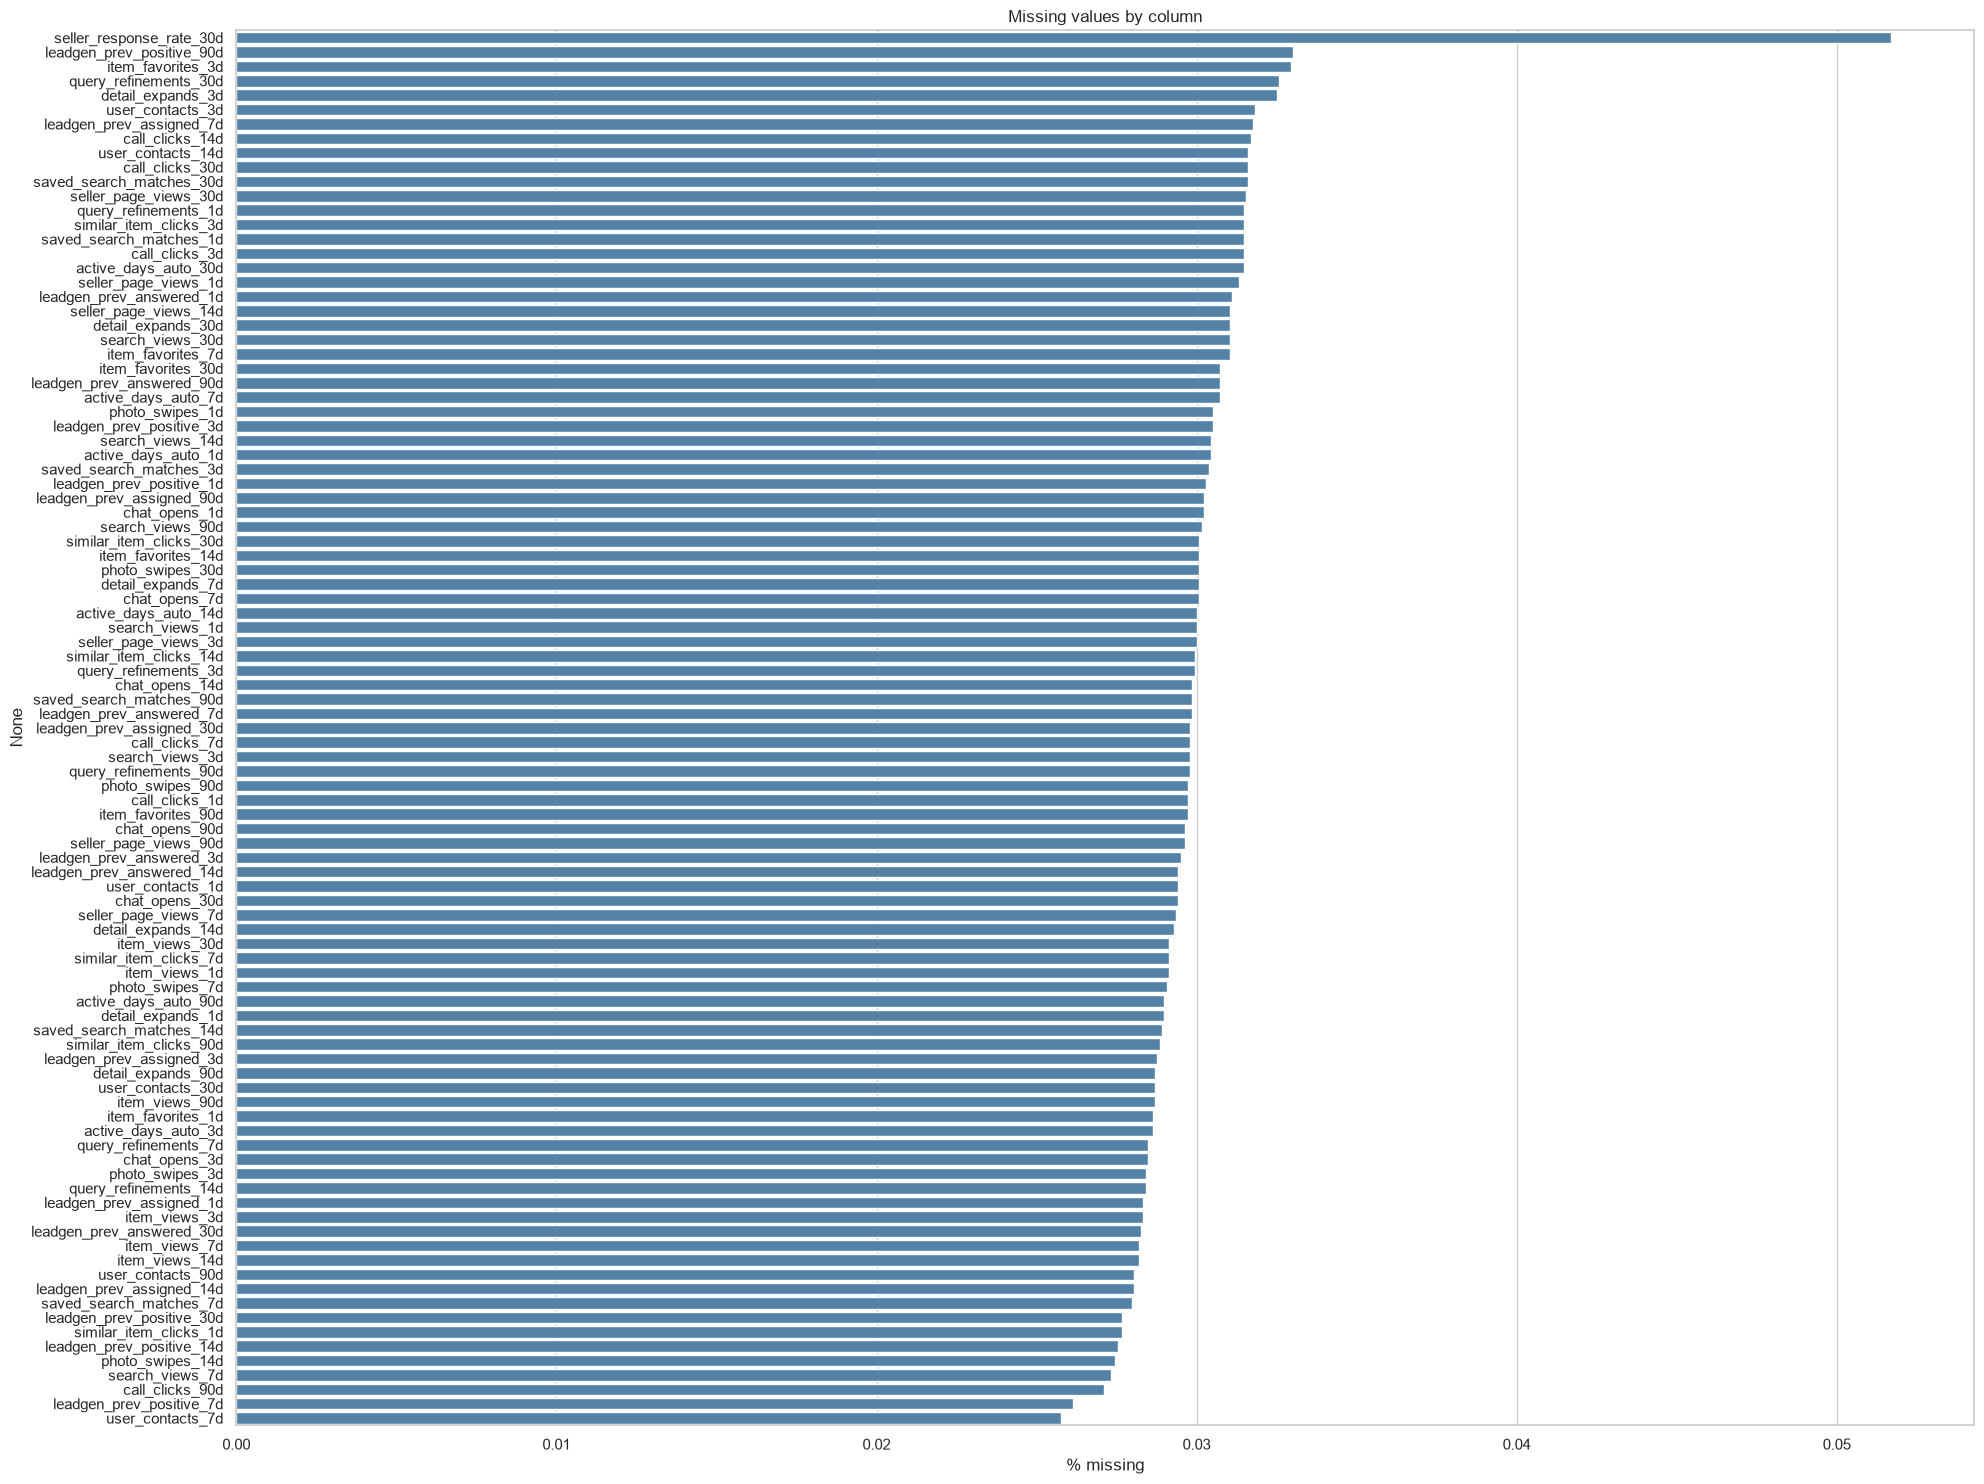

In [6]:
missing_share = df_train.isna().mean().sort_values(ascending=False)
missing_share = missing_share[missing_share > 0]

plt.figure(figsize=(20, 15))
sns.barplot(x=missing_share.values, y=missing_share.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

**Проверка 1. Статистический тест.** Сравниваю `user_age_days` у строк с пропуском в `item_views_30d` и без него. Если гипотеза верна, у группы с пропуском возраст аккаунта должен быть заметно меньше

In [7]:
from scipy.stats import mannwhitneyu

missing_mask = df_train["item_views_30d"].isna()

age_missing = df_train.loc[missing_mask, "user_age_days"].dropna()
age_present = df_train.loc[~missing_mask, "user_age_days"].dropna()

stat, pvalue = mannwhitneyu(age_missing, age_present, alternative="two-sided")

print("медиана user_age_days, пропуск:", age_missing.median())
print("медиана user_age_days, без пропуска:", age_present.median())
print("p-value:", round(pvalue, 4))

медиана user_age_days, пропуск: 325.0
медиана user_age_days, без пропуска: 285.0
p-value: 0.6907


**Проверка 2. Пропуски по разным колонкам — это одни и те же строки?** Если пропуск объясняется общей причиной (например, "нет истории вообще"), маски пропусков в разных колонках должны сильно коррелировать между собой. Строю матрицу корреляции масок пропусков по всем событийным агрегатам с окном 1d/7d/30d

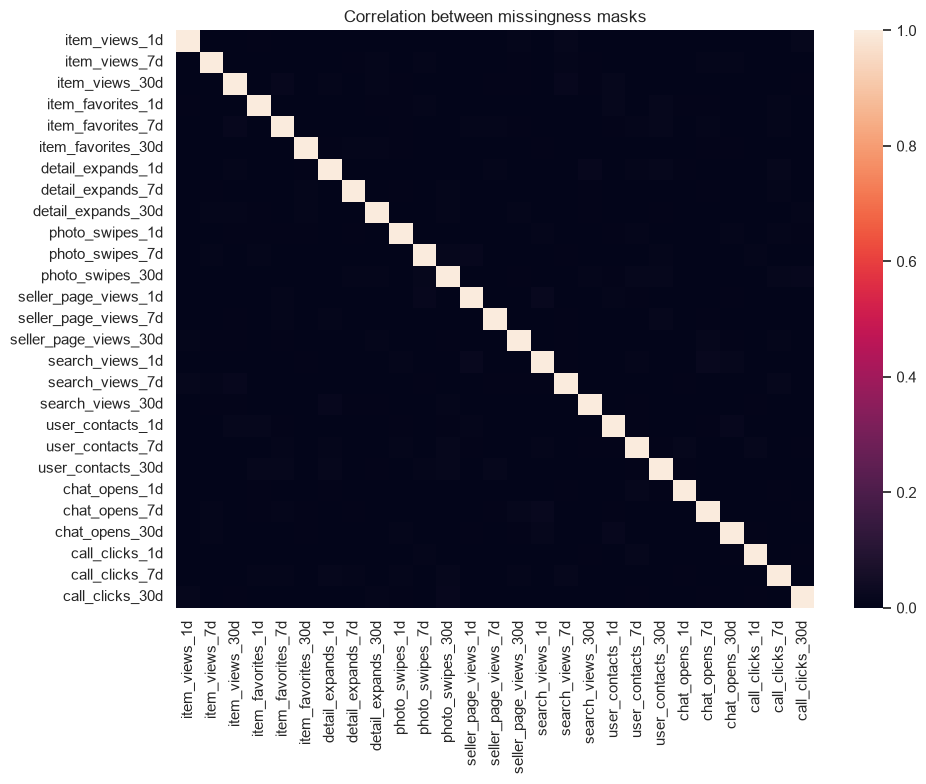

rows where ALL agg columns missing: 0
rows where ANY agg column missing: 7644


In [8]:
agg_prefixes = ("item_views", "item_favorites", "detail_expands", "photo_swipes",
                "seller_page_views", "search_views", "user_contacts", "chat_opens", "call_clicks")

agg_cols_eda = [c for c in df_train.columns if c.startswith(agg_prefixes) and c.endswith(("_1d", "_7d", "_30d"))]

missing_matrix = df_train[agg_cols_eda].isna()

plt.figure(figsize=(10, 8))
sns.heatmap(missing_matrix.corr(), cmap="rocket", vmin=0, vmax=1)
plt.title("Correlation between missingness masks")
plt.tight_layout()
plt.show()

print("rows where ALL agg columns missing:", missing_matrix.all(axis=1).sum())
print("rows where ANY agg column missing:", missing_matrix.any(axis=1).sum())

**Проверка 3. Пропуск и полное отсутствие событий в `events.csv`.** Если пропуск в табличном агрегате означает "у пользователя вообще нет истории", то у таких строк не должно быть событий в `events.csv`

In [9]:
rows_with_missing = df_train.loc[missing_matrix.any(axis=1), "lead_id"]
leads_with_events = set(df_events["lead_id"])

no_events_and_missing = rows_with_missing[~rows_with_missing.isin(leads_with_events)]
print(f"пропуск И нет событий вообще: {len(no_events_and_missing)} из {len(rows_with_missing)}")

пропуск И нет событий вообще: 9 из 7644


Все три проверки говорят об одном:

- p-value > 0.05 — статистически значимой разницы в `user_age_days` между группами нет
- корреляция масок пропусков между разными колонками близка к нулю (кроме диагонали) - пропуски в разных колонках происходят независимо, это не единый блок "нет истории"
- почти все строки с пропуском всё равно имеют события в `events.csv`

Гипотеза отвергнута - пропуски выглядят как случайный технический шум, а не как содержательный сигнал о пользователе. Поэтому я не создаю искусственные флаги вроде `is_new_user`/`has_no_history` и просто отдаю NaN модели как есть - CatBoost обрабатывает их нативно

## 4. Признаки из events.csv

`events.csv` даёт более детальную историю по каждому обращению. Строю признаки по типам событий и временным окнам, но сначала обязательно отрезаю все, что случилось после `assignment_ts`

Что считаю на выходе:
- количество событий каждого типа в окнах 1/3/7/30 дней до назначения
- recency — сколько часов прошло с последнего события каждого типа
- разнообразие контекста (`ctx_seq`, `src_slot`) и общее число событий

In [10]:
def build_event_features(df, events):
    base = df[["lead_id", "assignment_ts"]].copy()
    base["assignment_ts"] = pd.to_datetime(base["assignment_ts"])
    
    ev = events.copy()
    ev["event_ts"] = pd.to_datetime(ev["event_ts"])
    
    merged = ev.merge(base, on="lead_id")
    merged = merged[merged["event_ts"] < merged["assignment_ts"]].copy()
    merged["hours"] = (merged["assignment_ts"] - merged["event_ts"]).dt.total_seconds() / 3600

    frames = []
    windows = {"12h":12, "1d":24, "3d":72, "7d":168, "14d":336, "30d":720}
    
    for name, h in windows.items():
        w = merged[merged["hours"] <= h]
        cnt = w.groupby(["lead_id", "event_type"]).size().unstack(fill_value=0)
        cnt.columns = [f"ev_{c}_c_{name}" for c in cnt.columns]
        frames.append(cnt)
    
    rec = merged.groupby(["lead_id", "event_type"])["hours"].min().unstack()
    rec.columns = [f"ev_{c}_r" for c in rec.columns]
    frames.append(rec)
    
    agg = merged.groupby("lead_id").agg(
        ev_cnt=("event_type", "count"),
        ev_ctx=("ctx_seq", "nunique"),
        ev_slot=("src_slot", "nunique")
    )
    frames.append(agg)
    
    result = pd.concat(frames, axis=1).reindex(base["lead_id"]).reset_index()
    result = result.rename(columns={"index": "lead_id"})
    
    result = result.fillna(0)
    rec_cols = [c for c in result.columns if "_r" in c]
    result[rec_cols] = result[rec_cols].fillna(9999)
    
    return result

**Убрал target encoding, который пробовал раньше.** `te_user_id` был бесполезен: `user_id` встречается в train и test ровно по одному разу и не пересекается между выборками (см. проверку в 3.3), поэтому такой признак — почти сплошные пропуски и без сигнала. `te_region`/`te_car_segment` дублировали то, что CatBoost и так делает нативно с низкокардинальными категориями, только без сглаживания — источник лишнего шума, а не пользы.

In [11]:
train_event_feat = build_event_features(df_train, df_events)
test_event_feat = build_event_features(df_test, df_events)

df_train = df_train.merge(train_event_feat, on="lead_id", how="left")
df_test = df_test.merge(test_event_feat, on="lead_id", how="left")

print(df_train.shape, df_test.shape)


(13694, 157) (4306, 156)


## 5. Список признаков

Категориальные передаю в CatBoost как строки (с заполнением пропусков отдельным значением `"missing"`), числовые - как есть, без ручного impute

In [12]:
id_cols = ["lead_id", "user_id"]
time_cols = ["assignment_ts", "assignment_date"]
target_col = "target"

feature_cols = [c for c in df_train.columns if c not in id_cols + time_cols + [target_col]]
feature_cols = [c for c in feature_cols if c in df_test.columns]

cat_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df_train[c])]
num_features = [c for c in feature_cols if c not in cat_features]

for col in cat_features:
    df_train[col] = df_train[col].fillna("missing").astype(str).astype("category")
    df_test[col] = df_test[col].fillna("missing").astype(str).astype("category")

print(len(feature_cols), len(cat_features), len(num_features))


152 7 145


## 6. Метрика и валидация

Один time-based сплит дает оценку по одному конкретному отрезку дат - она может быть случайно удачной или неудачной. Созадаю честную кросс-валидацию по времени: несколько фолдов, где train - это все даты до окна валидации (expanding window), а validation - следующий блок дат

In [13]:
def daily_average_precision(y_true, y_score, dates):
    frame = pd.DataFrame({"y": y_true, "score": y_score, "date": dates})
    scores = []
    for _, group in frame.groupby("date"):
        if group["y"].sum() == 0:
            continue
        scores.append(average_precision_score(group["y"], group["score"]))
    return np.mean(scores)

In [14]:
from sklearn.model_selection import TimeSeriesSplit

date_values = sorted(df_train["assignment_date"].unique())
n_splits = 4
tscv = TimeSeriesSplit(n_splits=n_splits)

cv_folds = []
for train_idx, val_idx in tscv.split(date_values):
    train_dates = [date_values[i] for i in train_idx]
    val_dates_fold = [date_values[i] for i in val_idx]
    cv_folds.append((train_dates, val_dates_fold))

for i, (train_dates, val_dates_fold) in enumerate(cv_folds):
    print(f"fold {i}: train {train_dates[0]}..{train_dates[-1]} ({len(train_dates)}), val {val_dates_fold[0]}..{val_dates_fold[-1]} ({len(val_dates_fold)})")

fold 0: train 2026-04-07..2026-04-10 (4), val 2026-04-11..2026-04-13 (3)
fold 1: train 2026-04-07..2026-04-13 (7), val 2026-04-14..2026-04-16 (3)
fold 2: train 2026-04-07..2026-04-16 (10), val 2026-04-17..2026-04-19 (3)
fold 3: train 2026-04-07..2026-04-19 (13), val 2026-04-20..2026-04-22 (3)


In [15]:
def cross_validate(build_model_fn, folds):
    scores = []
    for train_dates, val_dates_fold in folds:
        train_mask = df_train["assignment_date"].isin(train_dates)
        val_mask = df_train["assignment_date"].isin(val_dates_fold)

        X_tr = df_train.loc[train_mask, feature_cols]
        y_tr = df_train.loc[train_mask, target_col]
        X_va = df_train.loc[val_mask, feature_cols]
        y_va = df_train.loc[val_mask, target_col]
        va_dates = df_train.loc[val_mask, "assignment_date"]

        model = build_model_fn()
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_va)
        scores.append(daily_average_precision(y_va.values, preds, va_dates.values))

    return np.mean(scores), np.std(scores)

In [16]:
dates = sorted(df_train["assignment_date"].unique())
cutoff = dates[int(len(dates) * 0.8)]

train_mask = df_train["assignment_date"] < cutoff
val_mask = ~train_mask

X_train = df_train.loc[train_mask, feature_cols]
y_train = df_train.loc[train_mask, target_col]
X_val = df_train.loc[val_mask, feature_cols]
y_val = df_train.loc[val_mask, target_col]
val_dates = df_train.loc[val_mask, "assignment_date"]

print(X_train.shape, X_val.shape)

(10272, 152) (3422, 152)


## 7. Модель-ансамбль и подбор гиперпараметров

Одна модель CatBoost имеет заметную дисперсию по `random_state`. Оформляю ансамбль CatBoost + LightGBM (разная механика деревьев и обработки категорий) в один класс с интерфейсом `fit`/`predict_proba`, чтобы дальше использовать его одинаково и в подборе гиперпараметров, и в кросс-валидации, и в финальном обучении

Для скорости подбор через Optuna гоняю на одном holdout-сплите (раздел 6) с одним seed на модель — полная кросс-валидация с бэггингом по нескольким seed'ам для 50+ trials была бы слишком долгой. После того как нашли лучшие параметры, честно перепроверяю их на кросс-валидации уже с несколькими seed'ами (раздел 8)

LightGBM — open-source библиотека, разворачивается локально, без внешних API

In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


class EnsembleModel:
    def __init__(self, cb_params=None, lgb_params=None, xgb_params=None, rf_params=None, lr_params=None, cat_features=None, seeds=(42,), weights=None):
        self.cb_params = cb_params
        self.lgb_params = lgb_params
        self.xgb_params = xgb_params
        self.rf_params = rf_params
        self.lr_params = lr_params
        self.cat_features = cat_features or []
        self.seeds = seeds
        self.weights = weights or {'cb': 1.0, 'lgb': 1.0, 'xgb': 1.0, 'rf': 1.0, 'lr': 1.0}
        self.cb_models = []
        self.lgb_models = []
        self.xgb_models = []
        self.rf_models = []
        self.lr_models = []
        self.preprocessor = None

    def fit(self, X, y):
        self.cb_models = []
        self.lgb_models = []
        self.xgb_models = []
        self.rf_models = []
        self.lr_models = []
        
        numeric_cols = [col for col in X.columns if col not in self.cat_features]
        
        self.preprocessor = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), self.cat_features)
        ])
        
        X_processed = self.preprocessor.fit_transform(X)
        
        for seed in self.seeds:
            if self.cb_params is not None:
                cb = CatBoostClassifier(**self.cb_params, cat_features=self.cat_features, random_state=seed, verbose=False)
                cb.fit(X, y, verbose=False)
                self.cb_models.append(cb)
            
            if self.lgb_params is not None:
                lgb = LGBMClassifier(**self.lgb_params, random_state=seed, verbose=-1)
                lgb.fit(X, y, categorical_feature=self.cat_features)
                self.lgb_models.append(lgb)
            
            if self.xgb_params is not None:
                xgb_params = self.xgb_params.copy()
                if 'verbose' in xgb_params:
                    del xgb_params['verbose']
                xgb = XGBClassifier(**xgb_params, random_state=seed)
                xgb.fit(X, y)
                self.xgb_models.append(xgb)
            
            if self.rf_params is not None:
                rf = RandomForestClassifier(**self.rf_params, random_state=seed, n_jobs=-1)
                rf.fit(X_processed, y)
                self.rf_models.append(rf)
            
            if self.lr_params is not None:
                lr_params = self.lr_params.copy()
                if 'n_jobs' in lr_params:
                    del lr_params['n_jobs']
                lr = LogisticRegression(**lr_params, random_state=seed, max_iter=1000)
                lr.fit(X_processed, y)
                self.lr_models.append(lr)
        
        return self

    def predict_proba(self, X):
        preds = []
        
        X_processed = self.preprocessor.transform(X)
        
        if self.cb_models:
            cb_preds = np.mean([m.predict_proba(X)[:, 1] for m in self.cb_models], axis=0)
            preds.append(cb_preds * self.weights.get('cb', 1.0))
        
        if self.lgb_models:
            lgb_preds = np.mean([m.predict_proba(X)[:, 1] for m in self.lgb_models], axis=0)
            preds.append(lgb_preds * self.weights.get('lgb', 1.0))
        
        if self.xgb_models:
            xgb_preds = np.mean([m.predict_proba(X)[:, 1] for m in self.xgb_models], axis=0)
            preds.append(xgb_preds * self.weights.get('xgb', 1.0))
        
        if self.rf_models:
            rf_preds = np.mean([m.predict_proba(X_processed)[:, 1] for m in self.rf_models], axis=0)
            preds.append(rf_preds * self.weights.get('rf', 1.0))
        
        if self.lr_models:
            lr_preds = np.mean([m.predict_proba(X_processed)[:, 1] for m in self.lr_models], axis=0)
            preds.append(lr_preds * self.weights.get('lr', 1.0))
        
        total_weight = sum(self.weights.values())
        return np.sum(preds, axis=0) / total_weight

In [29]:
def objective(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 3, 10)

    cb_params = dict(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=trial.suggest_float("cb_l2_leaf_reg", 1.0, 30.0, log=True),
        max_ctr_complexity=trial.suggest_int("max_ctr_complexity", 1, 4),
        auto_class_weights="Balanced",
        border_count=trial.suggest_int("border_count", 32, 255),
        subsample=trial.suggest_float("cb_subsample", 0.5, 1.0),
        random_strength=trial.suggest_float("random_strength", 0.1, 5.0, log=True),
    )
    
    lgb_params = dict(
        n_estimators=iterations,
        learning_rate=learning_rate,
        max_depth=depth,
        num_leaves=trial.suggest_int("lgb_num_leaves", 15, 255),
        class_weight="balanced",
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("lgb_subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 2.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 2.0),
    )
    
    xgb_params = dict(
        n_estimators=iterations,
        learning_rate=learning_rate,
        max_depth=depth,
        subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("xgb_reg_alpha", 0.0, 2.0),
        reg_lambda=trial.suggest_float("xgb_reg_lambda", 0.0, 2.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        tree_method="hist",
        enable_categorical=True,
    )
    
    rf_params = dict(
        n_estimators=trial.suggest_int("rf_n_estimators", 100, 500),
        max_depth=trial.suggest_int("rf_max_depth", 5, 20),
        min_samples_split=trial.suggest_int("rf_min_samples_split", 10, 100),
        min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 5, 50),
        max_features=trial.suggest_float("rf_max_features", 0.3, 0.9),
    )
    
    lr_params = dict(
        C=trial.suggest_float("lr_C", 0.01, 10.0, log=True),
        penalty=trial.suggest_categorical("lr_penalty", ["l1", "l2"]),
        solver="saga",
    )
    
    weights = {
        'cb': trial.suggest_float("w_cb", 0.0, 1.0),
        'lgb': trial.suggest_float("w_lgb", 0.0, 1.0),
        'xgb': trial.suggest_float("w_xgb", 0.0, 1.0),
        'rf': trial.suggest_float("w_rf", 0.0, 0.5),
        'lr': trial.suggest_float("w_lr", 0.0, 0.5),
    }

    score, _ = cross_validate(
        lambda: EnsembleModel(
            cb_params=cb_params,
            lgb_params=lgb_params,
            xgb_params=xgb_params,
            rf_params=rf_params,
            lr_params=lr_params,
            cat_features=cat_features,
            seeds=[42],
            weights=weights
        ),
        cv_folds
    )

    return score

In [31]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
study = optuna.create_study(
    direction="maximize", 
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE), 
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10))

study.optimize(objective, n_trials=100)

print(study.best_params)
print(study.best_value)

{'iterations': 868, 'learning_rate': 0.06113033106755852, 'depth': 4, 'cb_l2_leaf_reg': 23.418814049153685, 'max_ctr_complexity': 3, 'border_count': 176, 'cb_subsample': 0.7572124030206641, 'random_strength': 0.17157959105801224, 'lgb_num_leaves': 54, 'min_child_samples': 72, 'lgb_subsample': 0.9249424073604032, 'colsample_bytree': 0.5107978531943731, 'reg_alpha': 1.4492045085720549, 'reg_lambda': 0.6015465044845255, 'xgb_subsample': 0.8087084211197593, 'xgb_colsample_bytree': 0.5590215206085889, 'xgb_reg_alpha': 0.5447110694357407, 'xgb_reg_lambda': 0.7363946834274362, 'min_child_weight': 8, 'scale_pos_weight': 2.810643765712816, 'rf_n_estimators': 115, 'rf_max_depth': 14, 'rf_min_samples_split': 88, 'rf_min_samples_leaf': 21, 'rf_max_features': 0.30189879376230344, 'lr_C': 1.3749445899681105, 'lr_penalty': 'l2', 'w_cb': 0.506821763808073, 'w_lgb': 0.878275074195423, 'w_xgb': 0.5928232732073718, 'w_rf': 0.17837364240398884, 'w_lr': 0.13392920372432632}
0.6504104384370086


In [34]:
best = study.best_params

cb_params_final = dict(
    iterations=best["iterations"],
    learning_rate=best["learning_rate"],
    depth=best["depth"],
    l2_leaf_reg=best["cb_l2_leaf_reg"],
    max_ctr_complexity=best["max_ctr_complexity"],
    auto_class_weights="Balanced",
    border_count=best.get("border_count", 128),
    subsample=best.get("cb_subsample", 0.8),
    random_strength=best.get("random_strength", 1.0),
)

lgb_params_final = dict(
    n_estimators=best["iterations"],
    learning_rate=best["learning_rate"],
    max_depth=best["depth"],
    num_leaves=best["lgb_num_leaves"],
    class_weight="balanced",
    min_child_samples=best.get("min_child_samples", 20),
    subsample=best.get("lgb_subsample", 0.8),
    colsample_bytree=best.get("colsample_bytree", 0.8),
    reg_alpha=best.get("reg_alpha", 0.1),
    reg_lambda=best.get("reg_lambda", 0.1),
)

xgb_params_final = dict(
    n_estimators=best["iterations"],
    learning_rate=best["learning_rate"],
    max_depth=best["depth"],
    subsample=best.get("xgb_subsample", 0.8),
    colsample_bytree=best.get("xgb_colsample_bytree", 0.8),
    reg_alpha=best.get("xgb_reg_alpha", 0.1),
    reg_lambda=best.get("xgb_reg_lambda", 0.1),
    min_child_weight=best.get("min_child_weight", 3),
    scale_pos_weight=best.get("scale_pos_weight", 1.0),
    tree_method="hist",
    enable_categorical=True,
)

rf_params_final = dict(
    n_estimators=best.get("rf_n_estimators", 300),
    max_depth=best.get("rf_max_depth", 10),
    min_samples_split=best.get("rf_min_samples_split", 20),
    min_samples_leaf=best.get("rf_min_samples_leaf", 10),
    max_features=best.get("rf_max_features", 0.5),
)

lr_params_final = dict(
    C=best.get("lr_C", 1.0),
    penalty=best.get("lr_penalty", "l2"),
    solver="saga" if best.get("lr_penalty") == "l1" else "lbfgs",
)

weights_final = {
    'cb': best.get("w_cb", 0.4),
    'lgb': best.get("w_lgb", 0.3),
    'xgb': best.get("w_xgb", 0.2),
    'rf': best.get("w_rf", 0.05),
    'lr': best.get("w_lr", 0.05),
}

ENSEMBLE_SEEDS = [42, 43, 44]

cv_mean, cv_std = cross_validate(
    lambda: EnsembleModel(
        cb_params=cb_params_final,
        lgb_params=lgb_params_final,
        xgb_params=xgb_params_final,
        rf_params=rf_params_final,
        lr_params=lr_params_final,
        cat_features=cat_features,
        seeds=ENSEMBLE_SEEDS,
        weights=weights_final
    ),
    cv_folds,
)

print("CV Daily AP ансамбля:", cv_mean, "+-", cv_std)

CV Daily AP ансамбля: 0.6494514625592416 +- 0.03514685064188647


In [35]:
final_model = EnsembleModel(
    cb_params=cb_params_final,
    lgb_params=lgb_params_final,
    xgb_params=xgb_params_final,
    rf_params=rf_params_final,
    lr_params=lr_params_final,
    cat_features=cat_features,
    seeds=ENSEMBLE_SEEDS,
    weights=weights_final
)

final_model.fit(df_train[feature_cols], df_train[target_col])

test_preds = final_model.predict_proba(df_test[feature_cols])

## 9. Submission

Собираю файл в требуемом формате и прогоняю базовые проверки перед отправкой

In [36]:
submission = pd.DataFrame({
    "lead_id": df_test["lead_id"].astype(str),
    "score": test_preds,
})

submission.to_csv("submission.csv", index=False)
submission.head()

,lead_id,score
0,lead_97e409eb8f8c8246,0.422642
1,lead_55310edb4489f9e9,0.337435
2,lead_e7f653a2c6a7eee8,0.958943
3,lead_22f8e1cfc487ac20,0.062266
4,lead_48b638b839abfac3,0.242623


In [37]:
assert list(submission.columns) == ["lead_id", "score"]
assert len(submission) == len(df_test)
assert submission["lead_id"].is_unique
assert submission["score"].between(0, 1).all()

print("submission.csv готов")

submission.csv готов
